In [335]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imblearn openpyxl

In [419]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn import over_sampling
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

In [420]:
data1_df = pd.read_excel("data/credit_risk_file_1.xlsx")
data1_df

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.00,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.00,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.00,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.00,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.00,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,51332,3,0,3,1,0,0.333,0.00,1.000,0.000,...,0,2,0,0,0,0,3,1,24,5
51332,51333,4,2,2,0,1,0.000,0.25,0.500,0.500,...,0,2,0,0,0,2,2,0,74,7
51333,51334,2,1,1,1,1,0.500,0.50,0.500,0.500,...,0,2,0,0,0,0,2,0,9,5
51334,51335,2,1,1,0,0,0.000,0.00,0.500,0.500,...,0,2,0,0,0,0,2,0,15,8


In [421]:
data2_df = pd.read_excel("data/credit_risk_file_2.xlsx")
data2_df

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,51332,15,24,23,2,24,24,0,0,0,...,0.0,0.0,0.0,1.661,0,0,ConsumerLoan,ConsumerLoan,650,P4
51332,51333,57,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.520,0,0,others,others,702,P1
51333,51334,32,-99999,-99999,0,-99999,0,0,0,0,...,0.0,1.0,0.0,0.567,0,0,ConsumerLoan,others,661,P3
51334,51335,58,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,1.202,0,0,ConsumerLoan,others,686,P2


In [423]:
combined_df = pd.merge(data1_df, data2_df, on='PROSPECTID', how="inner")
combined_df

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.00,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.00,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.00,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.00,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.00,0.333,0.667,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,51332,3,0,3,1,0,0.333,0.00,1.000,0.000,...,0.0,0.0,0.0,1.661,0,0,ConsumerLoan,ConsumerLoan,650,P4
51332,51333,4,2,2,0,1,0.000,0.25,0.500,0.500,...,0.0,0.0,0.0,0.520,0,0,others,others,702,P1
51333,51334,2,1,1,1,1,0.500,0.50,0.500,0.500,...,0.0,1.0,0.0,0.567,0,0,ConsumerLoan,others,661,P3
51334,51335,2,1,1,0,0,0.000,0.00,0.500,0.500,...,0.0,0.0,0.0,1.202,0,0,ConsumerLoan,others,686,P2


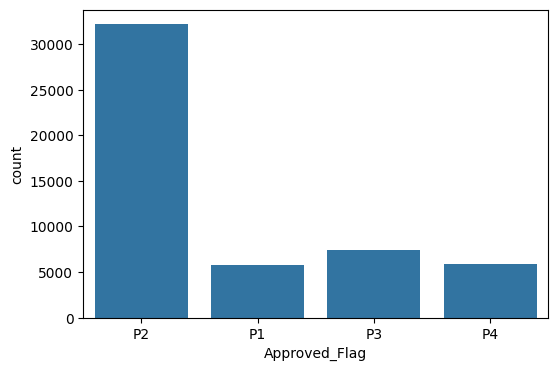

In [424]:
plt.figure(figsize=(6,4))
sns.countplot(x="Approved_Flag", data=combined_df)
plt.show()

In [425]:
le = LabelEncoder()
combined_df["Approved_Flag"] = le.fit_transform(combined_df["Approved_Flag"])
combined_df["Approved_Flag"]

0        1
1        1
2        1
3        1
4        0
        ..
51331    3
51332    0
51333    2
51334    1
51335    1
Name: Approved_Flag, Length: 51336, dtype: int64

In [426]:
corr = combined_df.select_dtypes(include=np.number).corr()
corr

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,Credit_Score,Approved_Flag
PROSPECTID,1.000000,-0.001858,0.000154,-0.006221,-0.002460,0.002525,-0.001665,0.005634,-0.004829,0.004829,...,-0.001352,0.003666,0.006387,0.002112,0.006415,-0.002104,0.003321,-0.000242,-0.008003,-0.009537
Total_TL,-0.001858,1.000000,0.956367,0.652481,0.408441,0.453666,-0.074973,-0.002687,-0.263300,0.263300,...,0.225026,0.071978,0.099260,0.031548,0.073229,0.176329,0.409390,0.098204,0.202859,-0.109168
Tot_Closed_TL,0.000154,0.956367,1.000000,0.402606,0.236070,0.388155,-0.140151,0.020013,-0.383012,0.383012,...,0.153221,0.020372,0.049458,-0.012132,0.029816,0.047898,0.417535,0.068004,0.206652,-0.116916
Tot_Active_TL,-0.006221,0.652481,0.402606,1.000000,0.667361,0.414587,0.128623,-0.060328,0.168503,-0.168503,...,0.307603,0.172670,0.182706,0.130309,0.152096,0.428211,0.199662,0.131294,0.099566,-0.038780
Total_TL_opened_L6M,-0.002460,0.408441,0.236070,0.667361,1.000000,0.505473,0.529940,0.087148,0.096540,-0.096540,...,0.244400,0.276576,0.223809,0.256616,0.213443,0.312958,0.120232,0.009713,-0.112826,0.123776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
max_unsec_exposure_inPct,-0.002104,0.176329,0.047898,0.428211,0.312958,0.130866,0.253858,-0.090238,0.330022,-0.330022,...,0.317171,0.227780,0.165445,0.205231,0.152432,1.000000,-0.097631,-0.010389,-0.066947,0.079222
HL_Flag,0.003321,0.409390,0.417535,0.199662,0.120232,0.140065,-0.099421,-0.038575,-0.343173,0.343173,...,0.006393,-0.030335,-0.002646,-0.040392,-0.007460,-0.097631,1.000000,0.015256,0.162458,-0.104577
GL_Flag,-0.000242,0.098204,0.068004,0.131294,0.009713,0.014198,-0.053952,-0.043672,0.014589,-0.014589,...,0.076200,-0.019397,0.012439,-0.030617,0.004384,-0.010389,0.015256,1.000000,0.149753,-0.111277
Credit_Score,-0.008003,0.202859,0.206652,0.099566,-0.112826,0.031527,-0.255157,-0.065349,-0.182756,0.182756,...,0.037956,-0.378722,-0.202295,-0.387340,-0.204150,-0.066947,0.162458,0.149753,1.000000,-0.835461


<Axes: >

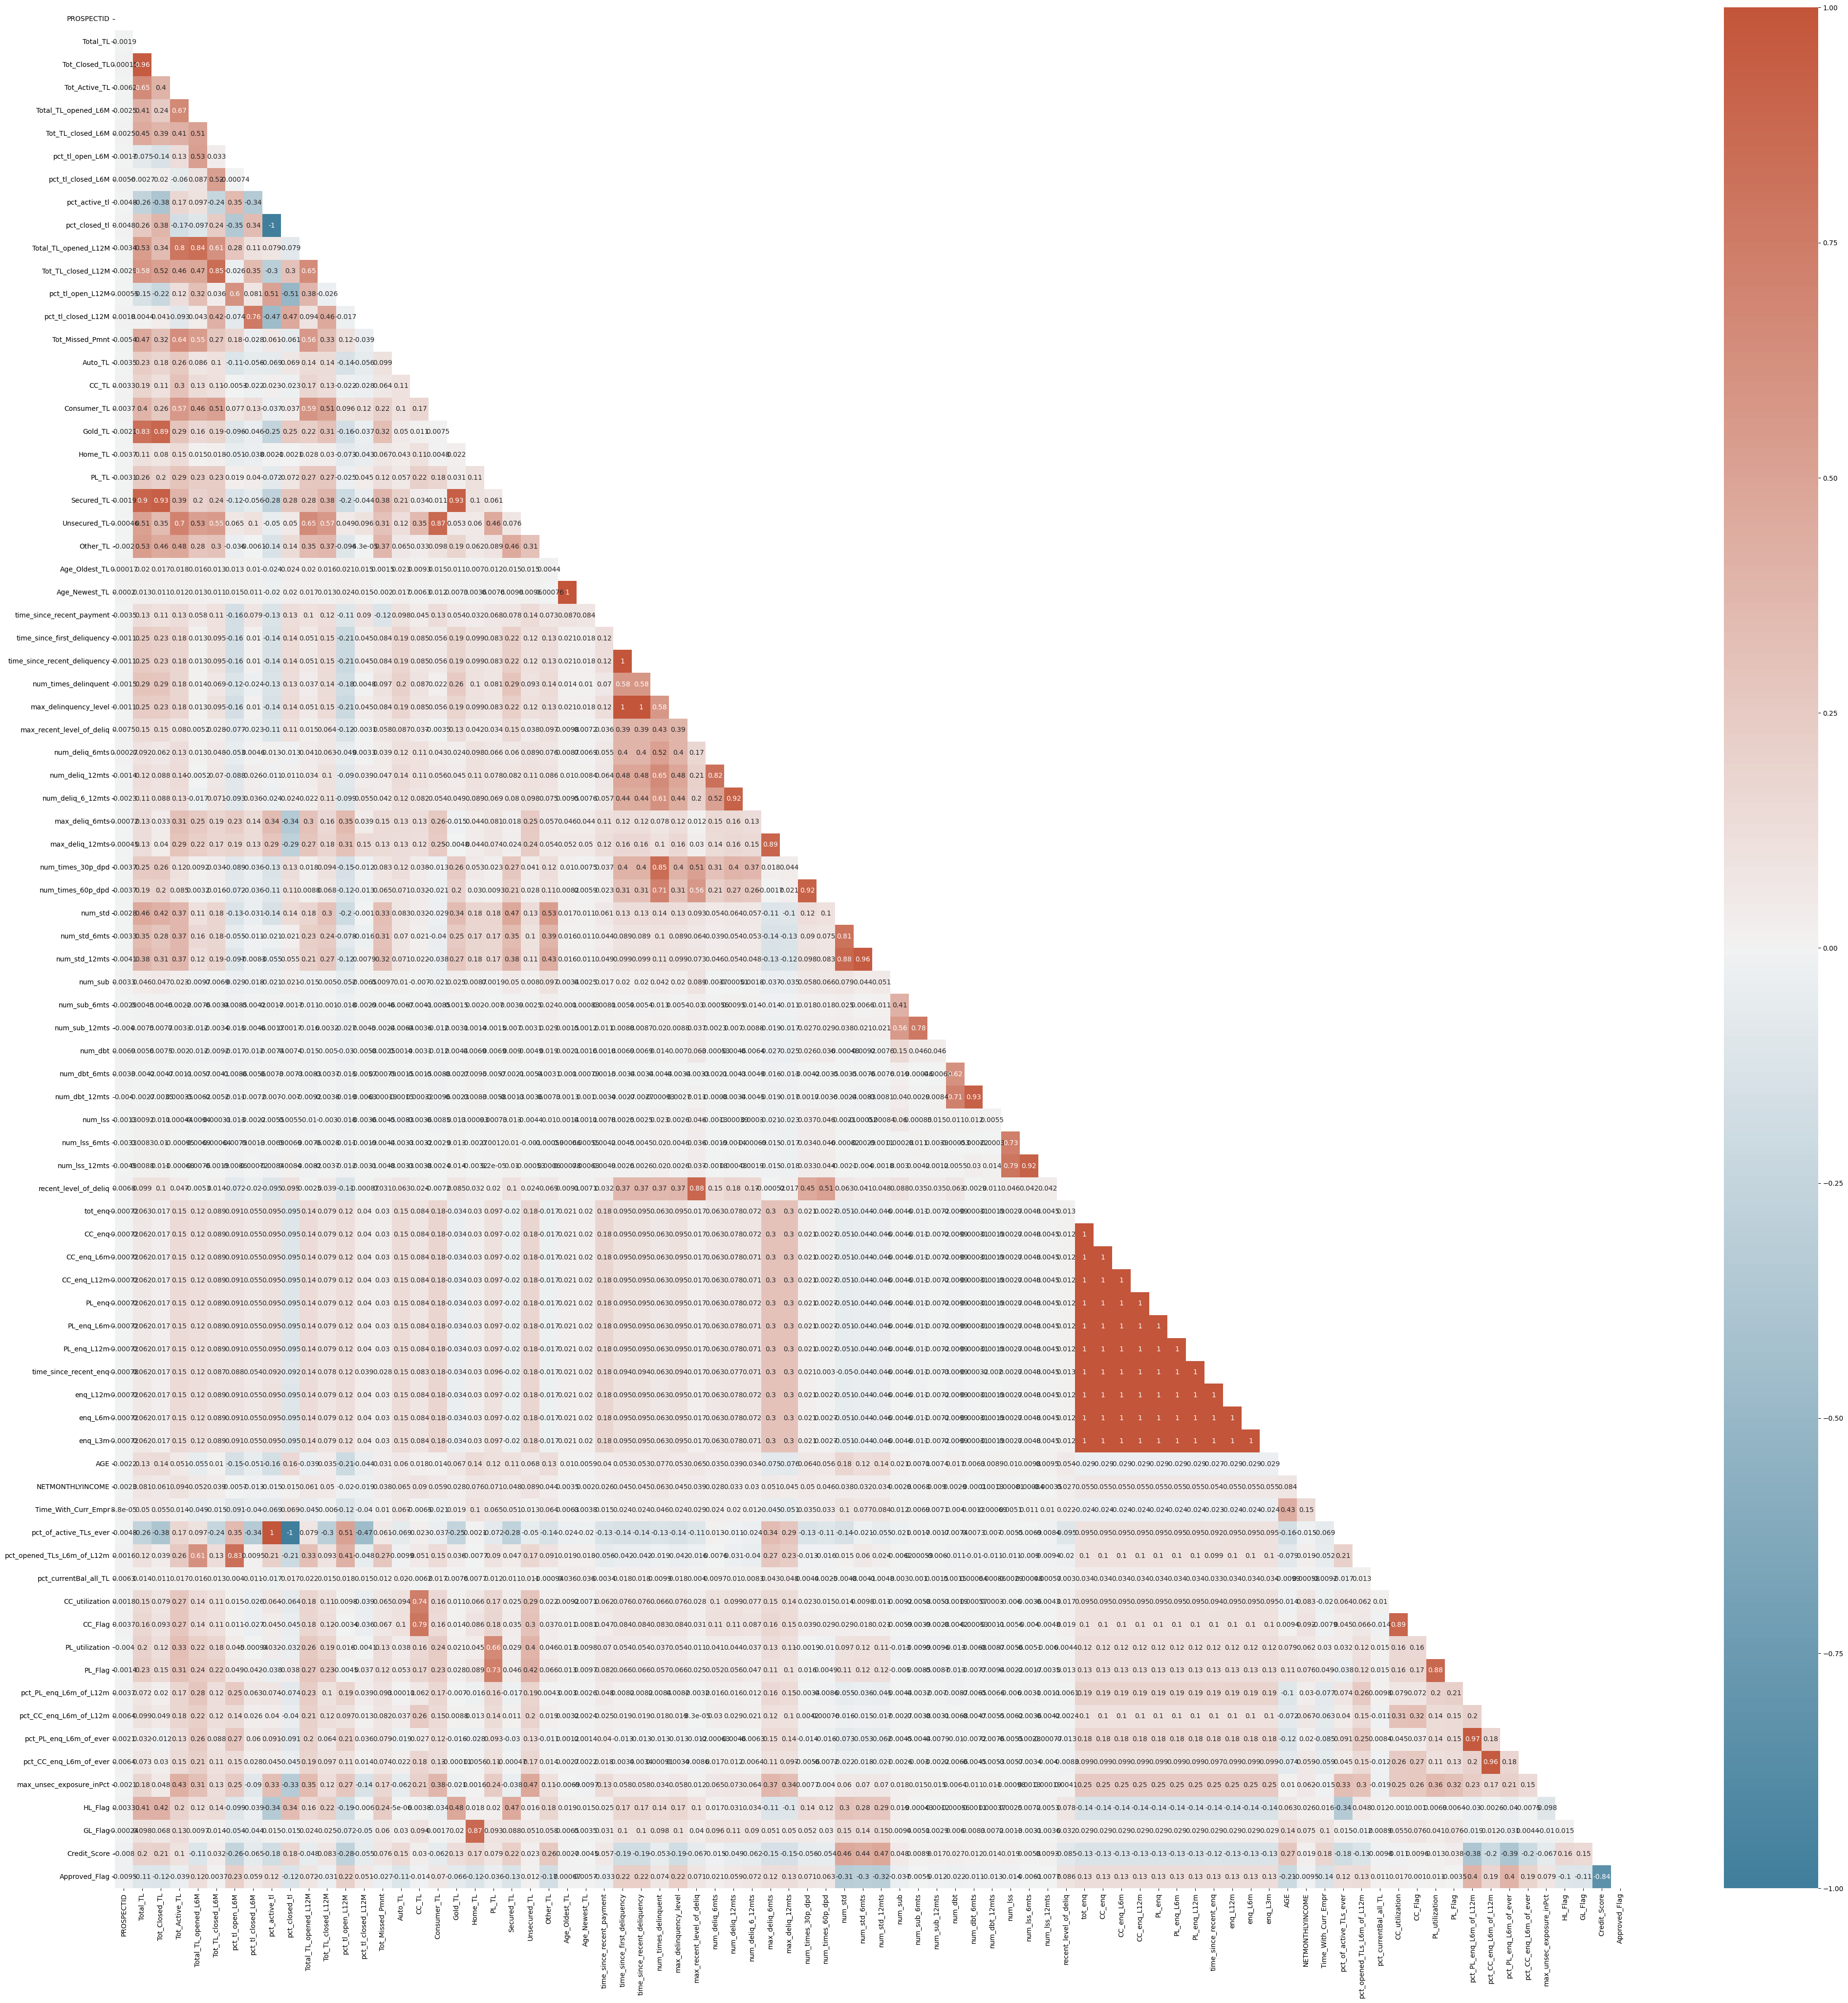

In [428]:
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(50,50))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True)

In [430]:
upper_triangle = corr.abs().where(np.triu(mask, k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] == 1)]
to_drop

['pct_of_active_TLs_ever']

In [431]:
combined_df = combined_df.drop(columns=to_drop, axis=1)

In [432]:
print("Num of missing values:")
print(combined_df.isnull().sum().sum())

Num of missing values:
0


In [434]:
X = combined_df.drop(columns=['PROSPECTID', 'Approved_Flag', 'Credit_Score'])
y = combined_df['Approved_Flag']

In [437]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_features

Index(['Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL', 'Total_TL_opened_L6M',
       'Tot_TL_closed_L6M', 'pct_tl_open_L6M', 'pct_tl_closed_L6M',
       'pct_active_tl', 'pct_closed_tl', 'Total_TL_opened_L12M',
       'Tot_TL_closed_L12M', 'pct_tl_open_L12M', 'pct_tl_closed_L12M',
       'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL', 'Consumer_TL', 'Gold_TL',
       'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL',
       'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment',
       'time_since_first_deliquency', 'time_since_recent_deliquency',
       'num_times_delinquent', 'max_delinquency_level',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
       'num_lss_12mts',

In [438]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns
categorical_features

Index(['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2',
       'first_prod_enq2'],
      dtype='object')

In [439]:
X[categorical_features].nunique()

MARITALSTATUS      2
EDUCATION          7
GENDER             2
last_prod_enq2     6
first_prod_enq2    6
dtype: int64

In [440]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

In [441]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessed_X_train = preprocessor.fit_transform(X_train)
preprocessed_X_test = preprocessor.transform(X_test)

In [442]:
preprocessed_X_train

array([[-0.39369795, -0.12630582, -0.90787193, ...,  0.        ,
         0.        ,  1.        ],
       [-0.532903  , -0.46273904, -0.47083512, ...,  0.        ,
         0.        ,  1.        ],
       [-0.532903  , -0.46273904, -0.47083512, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.71994241,  0.04191079,  2.15138575, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.41596763,  1.5558603 ,  0.4032385 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.532903  , -0.46273904, -0.47083512, ...,  0.        ,
         0.        ,  1.        ]], shape=(41068, 101))

In [443]:
y_train

50116    1
20307    1
29272    1
4417     1
831      3
        ..
38239    0
41713    2
33444    1
51324    0
858      1
Name: Approved_Flag, Length: 41068, dtype: int64

In [445]:
feature_names = preprocessor.get_feature_names_out()
len(feature_names)

101

In [446]:
smote = over_sampling.SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(preprocessed_X_train, y_train)

In [447]:
X_res

array([[-0.39369795, -0.12630582, -0.90787193, ...,  0.        ,
         0.        ,  1.        ],
       [-0.532903  , -0.46273904, -0.47083512, ...,  0.        ,
         0.        ,  1.        ],
       [-0.532903  , -0.46273904, -0.47083512, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.44013347, -0.29452243, -0.61662028, ...,  0.        ,
         0.        ,  0.33357639],
       [-0.15053268, -0.46273904,  0.72962357, ...,  0.        ,
         0.        ,  1.        ],
       [-0.45723991, -0.3713071 , -0.47083512, ...,  0.        ,
         1.        ,  0.        ]], shape=(103036, 101))

In [448]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(preprocessed_X_train)

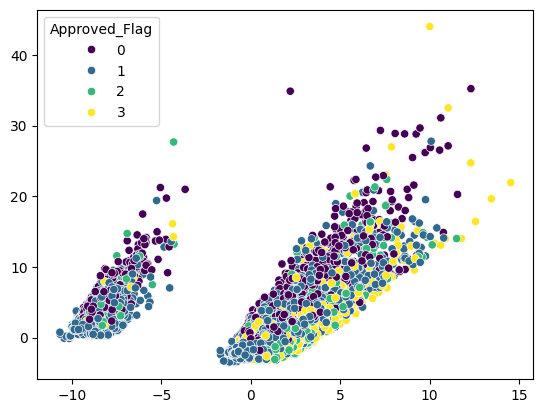

In [449]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette='viridis')
plt.show()

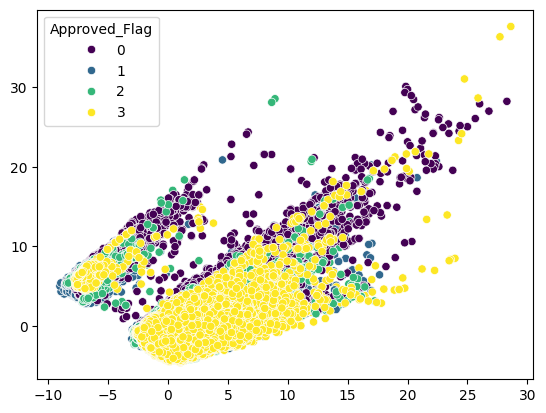

In [451]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_res)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_res, palette='viridis')
plt.show()

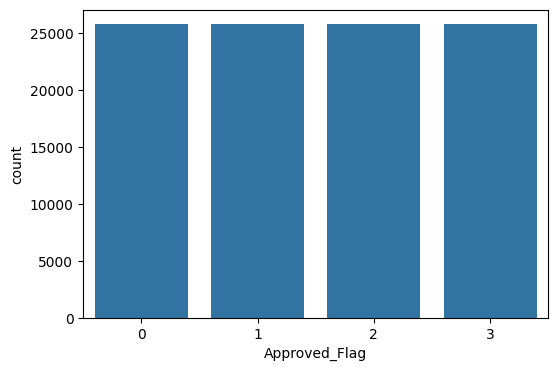

In [452]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.show()

In [453]:
lr_model = LogisticRegression(max_iter=1000)

lr_params = {
    'C': np.logspace(-4, 2, 7)
}

In [454]:
lr_search = RandomizedSearchCV(
    lr_model, lr_params, n_iter=5, scoring="f1", cv=4, n_jobs=-1, random_state=42
)
lr_search.fit(X_res, y_res)

RandomizedSearchCV(cv=4, estimator=LogisticRegression(max_iter=1000), n_iter=5,
                   n_jobs=-1,
                   param_distributions={'C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])},
                   random_state=42, scoring='f1')

In [455]:
def evaluate_model(model):
    y_pred = model.predict(preprocessed_X_test)
    print(classification_report(y_test, y_pred))

In [456]:
evaluate_model(lr_search.best_estimator_)

              precision    recall  f1-score   support

           0       0.41      0.82      0.55      1161
           1       0.86      0.54      0.66      6440
           2       0.26      0.33      0.29      1491
           3       0.40      0.68      0.50      1176

    accuracy                           0.56     10268
   macro avg       0.48      0.59      0.50     10268
weighted avg       0.67      0.56      0.58     10268



In [458]:
lr_search.best_params_

{'C': np.float64(0.0001)}

In [457]:
xgb_model = xgb.XGBClassifier()

xgb_params = {
    'max_depth': [7, 9, 10],         # Different depths for the trees
    'gamma': [0.1, 0.15, 0.3],         # Minimum loss reduction to make a split
    'alpha': [0.1, 0.15, 0.3],         # L1 regularization term on weights
    'reg_lambda': [1.5, 2, 2.5],          # L2 regularization term on weights
    'learning_rate': [0.02, 0.05, 0.1], # Learning rate
    'n_estimators': [200, 300, 400]   # Number of trees
}

In [ ]:
xgb_search = RandomizedSearchCV(
    xgb_model, xgb_params, n_iter=10, scoring="f1", cv=4, n_jobs=-1, random_state=42
)
xgb_search.fit(X_res, y_res)

In [ ]:
xgb_search.best_params_

In [ ]:
# {'reg_lambda': 1.5, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.3, 'alpha': 0.15}

In [459]:
model = xgb.XGBClassifier(reg_lambda=1.5, n_estimators=200, max_depth=9, learning_rate=0.1, gamma=0.3, alpha=0.15)

In [460]:
model.fit(X_res, y_res)

XGBClassifier(alpha=0.15, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.3, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [461]:
evaluate_model(model)

              precision    recall  f1-score   support

           0       0.78      0.83      0.80      1161
           1       0.86      0.91      0.88      6440
           2       0.46      0.32      0.38      1491
           3       0.76      0.78      0.77      1176

    accuracy                           0.80     10268
   macro avg       0.72      0.71      0.71     10268
weighted avg       0.78      0.80      0.79     10268



In [466]:
model.predict(preprocessed_X_test)

array([3, 1, 1, ..., 1, 0, 1], shape=(10268,))

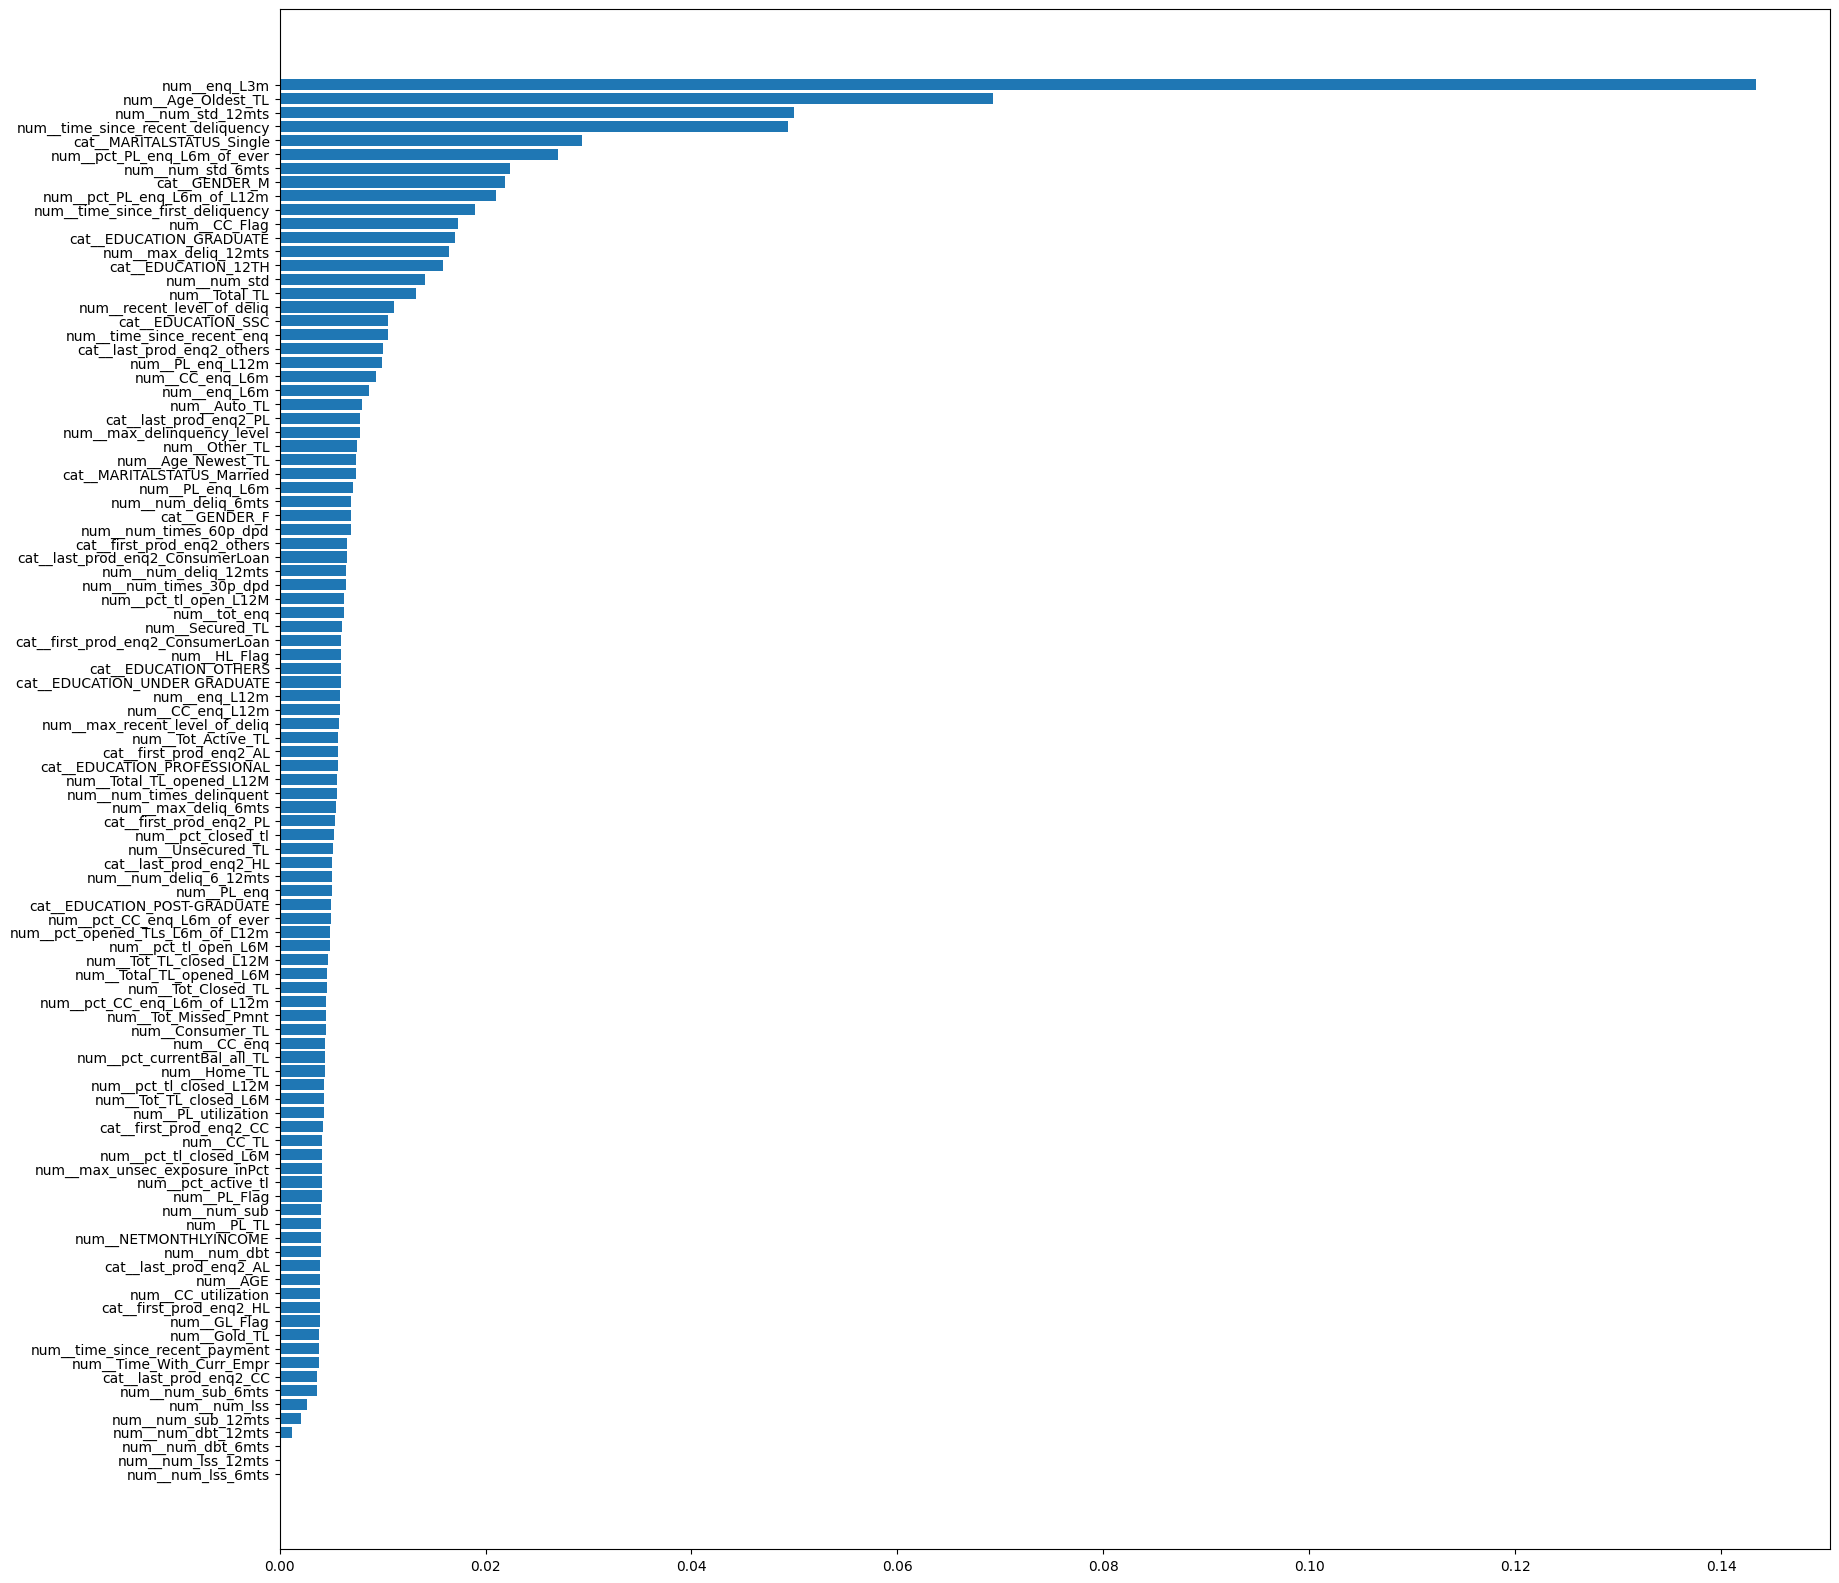

In [465]:
sorted_importances = model.feature_importances_.argsort()

plt.figure(figsize=(20,20))
plt.barh(feature_names[sorted_importances], model.feature_importances_[sorted_importances])
plt.show()